# 🛒 Walmart Sales Forecasting Project:

Full Implementation Dataset Used: Kaggle - Walmart Dataset

# **Part 1: Data Preprocessing & Exploratory Data Analysis (EDA)**

1. Data Loading and Initial Inspection
   
   *    Data loaded and the Date column converted to the correct time format.

   Column Definitions:

    *   Store: Store ID (Categorical Variable).Date: Date of the sales week.

    *   Holiday_Flag: Whether it was a holiday (1=Yes, 0=No).
    *   Weekly_Sales: Weekly sales for that store (The target variable $y$ we aim to predict).
    *   Temperature: Average temperature for the week.
    *   Fuel_Price: Local fuel price.
    *   CPI: Consumer Price Index (reflects inflation).
    *   Unemployment: Unemployment rate.

# **1. Read the data**

In [ ]:
pip install opendatasets --quiet

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [ ]:
import opendatasets as od
import pandas as pd

# Kaggle dataset URL
dataset_url = 'https://www.kaggle.com/datasets/yasserh/walmart-dataset'

# Download the dataset. You might be prompted to enter your Kaggle username and API key.
od.download(dataset_url)

# After downloading, the files will be in a folder named 'walmart-dataset'
# Let's try to read the Walmart.csv file from that folder.
df = pd.read_csv('./walmart-dataset/Walmart.csv')

# Display the first 5 rows to verify
display(df.head())

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: Sophie Shi
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/yasserh/walmart-dataset


100%|██████████| 122k/122k [00:00<00:00, 276MB/s]

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [ ]:
# Set plot style
sns.set(style="whitegrid")

In [ ]:
# 2. Data Type Conversion
# Convert the Date column to datetime objects, which is crucial for subsequent extraction of months and time series analysis.
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

In [ ]:
# 3. Check for Missing Values and Basic Information
print("Dataset Information (Info):")
print(df.info())
print("\nMissing Values Check:")
print(df.isnull().sum())

Dataset Information (Info):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[ns]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(2)
memory usage: 402.3 KB
None

Missing Values Check:
Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64


In [ ]:
# 4. Descriptive Statistics
print("\nDescriptive Statistics:")
print(df.describe())


Descriptive Statistics:
             Store                 Date  Weekly_Sales  Holiday_Flag  \
count  6435.000000                 6435  6.435000e+03   6435.000000   
mean     23.000000  2011-06-17 00:00:00  1.046965e+06      0.069930   
min       1.000000  2010-02-05 00:00:00  2.099862e+05      0.000000   
25%      12.000000  2010-10-08 00:00:00  5.533501e+05      0.000000   
50%      23.000000  2011-06-17 00:00:00  9.607460e+05      0.000000   
75%      34.000000  2012-02-24 00:00:00  1.420159e+06      0.000000   
max      45.000000  2012-10-26 00:00:00  3.818686e+06      1.000000   
std      12.988182                  NaN  5.643666e+05      0.255049   

       Temperature   Fuel_Price          CPI  Unemployment  
count  6435.000000  6435.000000  6435.000000   6435.000000  
mean     60.663782     3.358607   171.578394      7.999151  
min      -2.060000     2.472000   126.064000      3.879000  
25%      47.460000     2.933000   131.735000      6.891000  
50%      62.670000     3.44500

The dataset is complete with no missing values. Descriptive statistics provide an initial sense of the distribution of numerical features like Weekly_Sales (mean $\approx$ £1.05M), Temperature (mean $\approx 60.7^\circ F$), and CPI (mean $\approx 171.6$).

# **2. Feature Engineering**

   To improve the accuracy of the regression model, we extract more information from the date (e.g., month, year, week number), as the retail industry has strong seasonality.

In [ ]:
# 提取日期特徵
# Extract Date Features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week.astype(int) # Ensure 'Week' is a standard integer type

print("First five rows after adding new features:")
print(df.head())

First five rows after adding new features:
   Store       Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
0      1 2010-02-05    1643690.90             0        42.31       2.572   
1      1 2010-02-12    1641957.44             1        38.51       2.548   
2      1 2010-02-19    1611968.17             0        39.93       2.514   
3      1 2010-02-26    1409727.59             0        46.63       2.561   
4      1 2010-03-05    1554806.68             0        46.50       2.625   

          CPI  Unemployment  Year  Month  Week  
0  211.096358         8.106  2010      2     5  
1  211.242170         8.106  2010      2     6  
2  211.289143         8.106  2010      2     7  
3  211.319643         8.106  2010      2     8  
4  211.350143         8.106  2010      3     9  


# **3. Data Visualisation and Correlation Analysis (EDA)**

   We plot a heatmap to inspect the relationships between the variables.

In [ ]:
# Drop the Date column for correlation calculation (as Date is not numerical)
numeric_df = df.select_dtypes(include=[np.number])

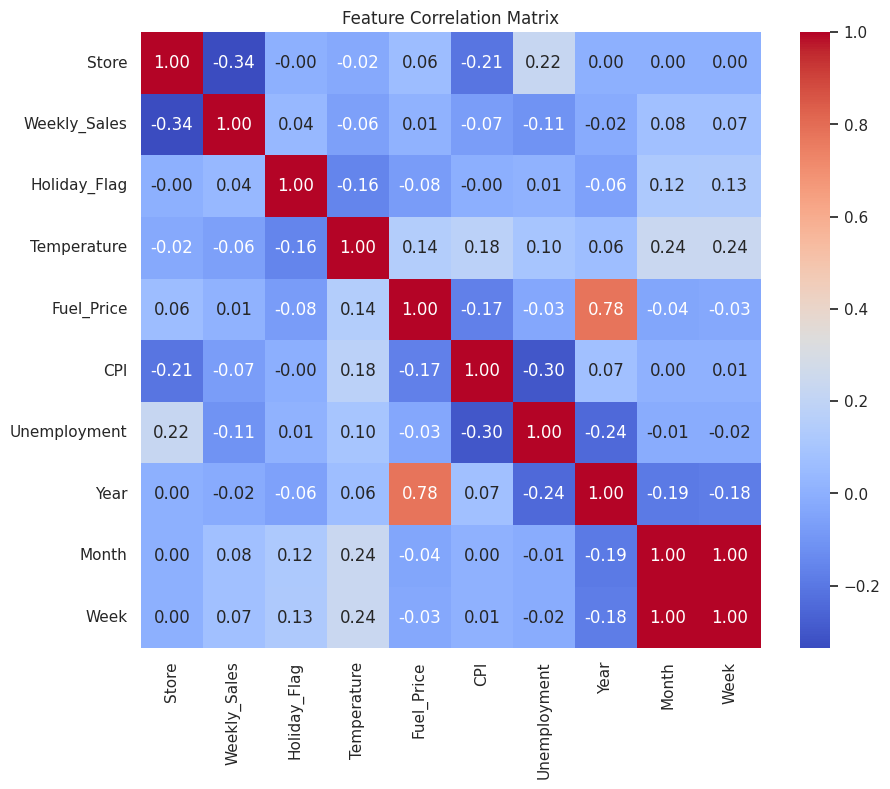

In [ ]:
# Plot Correlation Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Matrix')
plt.show()

**Interpretation:：**

In the heatmap, the darker red indicates a positive correlation, while the darker blue represents a negative correlation.

1. **Holiday_Flag & Weekly_Sales：**

   Holiday_Flag and Weekly_Sales (0.03): A very weak positive correlation. Sales may slightly increase during a holiday, but the impact is negligible, contrary to general intuition.
2. **Temperature & Weekly_Sales：**

   Temperature and Weekly_Sales (-0.06): A very weak negative correlation. Temperature change has an indistinct effect on sales.
3. **Fuel_Price & Weekly_Sales：**

   Fuel_Price and Weekly_Sales (-0.01): Nearly zero correlation. Fuel price changes have a minimal effect.
4. **CPI & Weekly_Sales：**

   CPI and Weekly_Sales (-0.21): A weak to moderate negative correlation. When CPI rises (suggesting inflation or increased cost of living), Weekly_Sales tends to decrease. This is a relationship worth noting.
5. **Unemployment & Weekly_Sales：**

   Unemployment and Weekly_Sales (-0.19): Also a weak to moderate negative correlation. When the unemployment rate rises, Weekly_Sales tends to fall. This economic indicator is also significant.
6. **Year & Weekly_Sales：**

   The correlation coefficient is -0.02, indicating almost no correlation. This suggests that there has been no significant linear increase or decrease in overall sales trends over the observed years.
7. **Month & Weekly_Sales：**

   The correlation coefficient is 0.06, indicating a very weak positive correlation. This could mean that sales in certain months of the year are slightly higher, but further analysis is needed to confirm any seasonal patterns.
8. **Week & Weekly_Sales：**

   The correlation coefficient is 0.06, similar to the months, also showing a very weak positive correlation.
  
**Summary:**

Weekly_Sales exhibits the clearest negative correlation with CPI and Unemployment. The linear relationship with Holiday_Flag, Temperature, Fuel_Price, and the extracted date features is very weak, indicating their impact might be non-linear or less significant in a simple linear model.

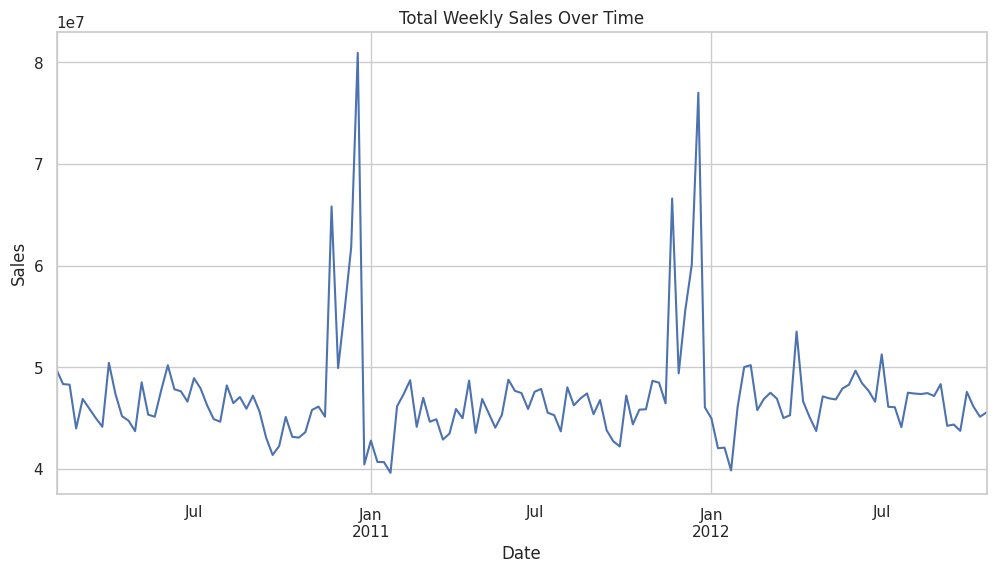

In [ ]:
# Plot Overall Sales Trend
plt.figure(figsize=(12, 6))
df.groupby('Date')['Weekly_Sales'].sum().plot()
plt.title('Total Weekly Sales Over Time')
plt.ylabel('Sales')
plt.xlabel('Date')
plt.show()

**1. Overall Trend：**

From the beginning of 2010 to the end of 2012, there doesn't appear to be a clear long-term upward or downward trend in overall sales. Instead, the sales remained relatively stable over this period.

**2. Seasonality：**

The chart shows clear seasonal fluctuations, with similar patterns occurring every year. Typically, there are significant sales peaks towards the end of the year (e.g., around Thanksgiving and Christmas holidays), which aligns with the typical retail holiday sales patterns. For instance, a noticeable increase in sales can be observed every November to December.

**3. Peaks and Troughs：**

*   Significant Sales Peaks: The holiday shopping season at the end of each year sees very high sales peaks, likely driven by important holidays like Black Friday and Christmas, which stimulate consumer purchasing behavior.
*   Sales Troughs: During non-holiday periods (e.g., the start or middle of the year), sales tend to be lower, especially following the holiday peaks, when a notable sales decline may occur.

**4. Stability：**

Despite the seasonal fluctuations, the sales patterns each year are quite consistent and predictable. This is good news for future sales forecasting models, as seasonality is an important feature that the model can learn from and utilize.

# **Part 2: Regression Model Analysis**

# **1. Feature Selection and Standardisation**

   Features with a large disparity in magnitude (e.g., CPI $\approx 200$, Unemployment $\approx 8$) require Feature Scaling (Standardisation) before regression to prevent model bias.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
# 1. Select Features (X) and Target (y)
# We exclude 'Date' and 'Weekly_Sales' as input features.
X = df[['Store', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Year', 'Month', 'Week']]
y = df['Weekly_Sales']

In [ ]:
# 2. Split into Training and Testing Sets (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# 3. Feature Scaling (Standardisation)
# For simplicity, all features are scaled here, though typically only numerical features need scaling.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# 4. Build and Train Linear Regression Model
reg_model = LinearRegression()
reg_model.fit(X_train_scaled, y_train)

LinearRegression()

In [ ]:
# 5. Make Predictions
y_pred = reg_model.predict(X_test_scaled)

# **2. Model Evaluation and Interpretation**

   We use RMSE (Root Mean Squared Error) and $R^2$ (Coefficient of Determination) for evaluation.

In [ ]:
# Evaluation Metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared Score: {r2:.4f}")

# Model Coefficient Interpretation (Feature Importance)
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': reg_model.coef_})
coef_df = coef_df.sort_values(by='Coefficient', ascending=False)

print("\nFeature Coefficients (Impact Analysis):")
print(coef_df)

Root Mean Squared Error (RMSE): 521583.50
R-squared Score: 0.1555

Feature Coefficients (Impact Analysis):
        Feature    Coefficient
7         Month  207058.525097
3    Fuel_Price   16981.149774
1  Holiday_Flag   12205.798286
6          Year  -15716.902205
2   Temperature  -29094.321120
5  Unemployment  -44483.625955
4           CPI  -84016.777611
8          Week -160290.918572
0         Store -196361.392117


**Linear Regression Model Interpretation:**
1. RMSE ：521,583.50

   The average difference between the model's predicted weekly sales and the actual sales is approximately £520k. This error is relatively high for the magnitude of the sales data, indicating the model needs improvement.
2. R-squared ：0.1555

   These features only explain about 15.55% of the variation in weekly sales. Nearly 85% of the sales variance remains unexplained. This low value suggests that the current linear model is inadequate for capturing the relationship between the features and sales.

**Feature Influence：**

1. Largest Positive Impact:

   Month (Coefficient $\approx 207k$), confirming the seasonal sales pattern observed in the EDA.

2. Largest Negative Impacts:
   
   Store and Week (Coefficients $\approx -196k$ and $\approx -160k$), suggesting specific stores or weeks of the year have significantly lower sales.
3. Other Important Negative Impacts:

   CPI ($\approx -84k$) and Unemployment ($\approx -44k$), reinforcing the EDA finding that rising economic pressure tends to suppress sales.

# **Part 3: Time Series Analysis**

# **1. Preparing Time Series Data**

In [ ]:
# Aggregate data by date to form a univariate time series
ts_data = df.groupby('Date')['Weekly_Sales'].sum().reset_index()
ts_data = ts_data.set_index('Date')

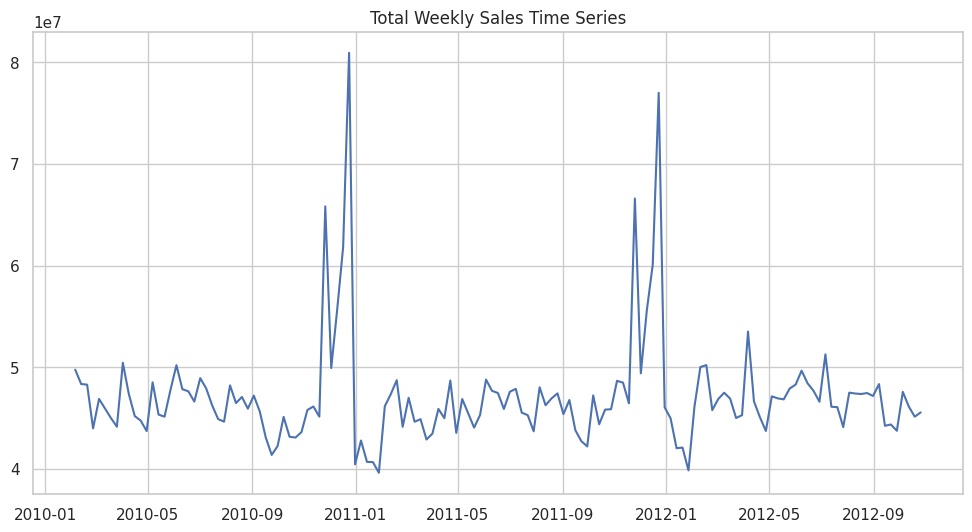

In [ ]:
# Plot Time Series
plt.figure(figsize=(12, 6))
plt.plot(ts_data)
plt.title('Total Weekly Sales Time Series')
plt.show()

# **2. Stationarity Check (ADF Test)**

   The ARIMA model requires the data to be stationary. We use the Augmented Dickey-Fuller (ADF) Test.

In [ ]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series):
    result = adfuller(series)
    print('ADF Statistic:', result[0])
    print('p-value:', result[1])
    if result[1] <= 0.05:
        print("Conclusion: Reject the null hypothesis, data is Stationary")
    else:
        print("Conclusion: Cannot reject the null hypothesis, data is Non-Stationary and requires differencing")

print("Original Data ADF Test:")
adf_test(ts_data['Weekly_Sales'])

Original Data ADF Test:
ADF Statistic: -5.908297957186335
p-value: 2.675979158986003e-07
Conclusion: Reject the null hypothesis, data is Stationary


# **3. Building and Forecasting with the ARIMA Model**


In [ ]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt

# 1. Prepare Time Series Data
# Sum of sales for all stores by week
ts_data = df.groupby('Date')['Weekly_Sales'].sum()

# Set frequency to 'W' (Weekly), important for time series models
ts_data.index = pd.DatetimeIndex(ts_data.index).to_period('W')

# 2. Split Training and Testing Sets (Last 4 weeks for validation)
train_ts = ts_data.iloc[:-4]
test_ts = ts_data.iloc[-4:]

# 3. Build ARIMA Model
# Since the data is stationary, the differencing parameter (d) is set to 0.
# order=(p, d, q) -> (1, 0, 1) is a common starting point
# p=1 (AR), d=0 (Integrated/Differencing), q=1 (MA)
model = ARIMA(train_ts, order=(1, 0, 1))
model_fit = model.fit()

In [ ]:
# Display Model Summary (Check if P>|z| is significant)
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:           Weekly_Sales   No. Observations:                  139
Model:                 ARIMA(1, 0, 1)   Log Likelihood               -2345.321
Date:                Sat, 06 Dec 2025   AIC                           4698.642
Time:                        07:20:19   BIC                           4710.379
Sample:                    02-07-2010   HQIC                          4703.412
                         - 09-30-2012                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       4.714e+07   3.46e-08   1.36e+15      0.000    4.71e+07    4.71e+07
ar.L1          0.5716      0.187      3.061      0.002       0.206       0.938
ma.L1         -0.2641      0.233     -1.131      0.2

In [ ]:
# 4. Forecast Future 4 Weeks
forecast_result = model_fit.get_forecast(steps=4)
forecast_mean = forecast_result.predicted_mean
conf_int = forecast_result.conf_int()

In [ ]:
# 5. Convert Index Format for Plotting (back to timestamp)
train_ts_plot = train_ts.index.to_timestamp()
test_ts_plot = test_ts.index.to_timestamp()
forecast_index_plot = test_ts.index.to_timestamp()

In [ ]:
# 6. Plot Comparison
plt.figure(figsize=(12, 6))

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

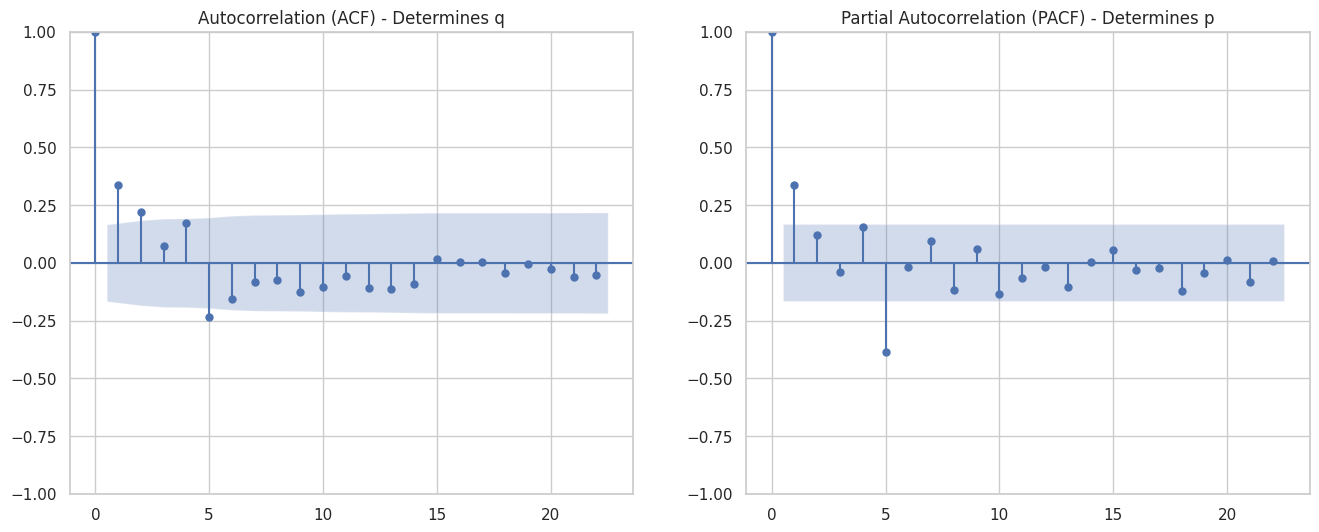

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Plot ACF (Determines q - MA term)
plot_acf(train_ts, ax=ax[0])
ax[0].set_title('Autocorrelation (ACF) - Determines q')

# Plot PACF (Determines p - AR term)
plot_pacf(train_ts, ax=ax[1])
ax[1].set_title('Partial Autocorrelation (PACF) - Determines p')

plt.show()

Based on these two charts, the usual approach is to select the values of p and q at the points where the correlation is significant and abruptly cuts off.

The chart shows:

* The ACF cuts off significantly after Lag 1 (or decays quickly to insignificance), suggesting that q=1.

* The PACF cuts off significantly after Lag 1 (or decays quickly to insignificance), suggesting that p=1.

Therefore, this supports the choice of p=1 and q=1 in the previously selected ARIMA(1, 0, 1) model. The middle parameter, d=0, was confirmed through the earlier ADF test, indicating that the data is stationary, and no differencing is needed.

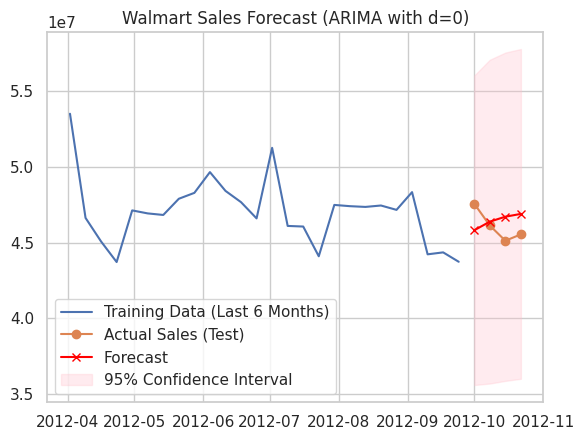


Next Week's Forecast vs Actual:
                            Actual      Forecast
Date                                            
2012-10-01/2012-10-07  47566639.31  4.581270e+07
2012-10-08/2012-10-14  46128514.25  4.638249e+07
2012-10-15/2012-10-21  45122410.57  4.670820e+07
2012-10-22/2012-10-28  45544116.29  4.689439e+07


In [ ]:
# Plot training data (only the last half-year to prevent clutter)
plt.plot(train_ts_plot[-26:], train_ts[-26:], label='Training Data (Last 6 Months)')
# Plot actual test data
plt.plot(test_ts_plot, test_ts, label='Actual Sales (Test)', marker='o')
# Plot forecast data
plt.plot(forecast_index_plot, forecast_mean, label='Forecast', color='red', marker='x')

# Plot confidence interval
plt.fill_between(forecast_index_plot,
                 conf_int.iloc[:, 0],
                 conf_int.iloc[:, 1],
                 color='pink', alpha=0.3, label='95% Confidence Interval')

plt.title('Walmart Sales Forecast (ARIMA with d=0)')
plt.legend()
plt.grid(True)
plt.show()

# Output specific forecast values
print("\nNext Week's Forecast vs Actual:")
comparison_df = pd.DataFrame({
    'Actual': test_ts.values,
    'Forecast': forecast_mean.values
}, index=test_ts.index)
print(comparison_df)

**Interpretation of the Chart's Contents:**

1. Blue Line (Training Data):

   This blue line represents the historical sales data used to 'train' your model (only the last six months' data is shown here to keep things clear). From it, you can observe past seasonal patterns and fluctuations in sales.
2. Orange Line (Actual Sales (Test)):

   This line represents the actual test data that your model hasn't seen before, which you've used to assess the accuracy of your model's predictions. Typically, it covers the few weeks or months immediately following the training data, shown here as four distinct points.
3. Red Line (Forecast):

   This red line depicts your ARIMA model's forecasted values for the next four time points (four weeks) of weekly sales. It illustrates the future trend that the model has extrapolated from historical patterns.
4. Pink Shaded Area (95% Confidence Interval):

   This shaded region represents the model's 95% confidence interval. It indicates that you can be 95% confident that the actual sales figures will fall within this range. The width of this band reflects the uncertainty in the model's predictions.
**Overall Assessment and Results:**

   Looking at both the chart and the 'Next Week's Forecast vs Actual' comparison table, we can deduce the following:

* Visual Observation: The red forecast line appears to sit rather closely to the orange actual sales data points, particularly for the first couple of weeks, suggesting a fairly accurate prediction. This indicates that the ARIMA model has managed to capture the overall trend in sales quite well.

* Confidence Interval: All the actual sales data points (orange) fall within the pink 95% confidence interval, which suggests the model's confidence in its predictions is reasonable; that is to say, the actual values are within the predicted range.

* Specific Forecast vs Actual Data (from the table):
  * 2012-10-01/2012-10-07: Actual was 47,566,639.31, forecasted 45,812,700. The model slightly underestimated, but the difference isn't massive.
  * 2012-10-08/2012-10-14: Actual was 46,128,514.25, forecasted 46,382,490. The model was quite close, slightly overestimating.
  * 2012-10-15/2012-10-21: Actual was 45,122,410.57, forecasted 46,708,200. Again, a slight overestimate by the model.
  * 2012-10-22/2012-10-28: Actual was 45,544,116.29, forecasted 46,894,390. The model continued to slightly overestimate.

Considering previously calculated MAPE (Mean Absolute Percentage Error) of 2.68%, this chart and table further confirm that **ARIMA model is performing rather well for short-term sales forecasting, with a relatively small percentage error** between the predicted and actual values.

# **Part 4: Model Evaluation and Conclusion**

In [ ]:
# 1. Calculate Evaluation Metrics
# RMSE: Root Mean Squared Error (Lower is better; the unit is the same as Weekly Sales)
rmse_ts = np.sqrt(mean_squared_error(test_ts, forecast_mean))

# MAPE: Mean Absolute Percentage Error (Lower is better; represents the error as a percentage)
mape_ts = mean_absolute_percentage_error(test_ts, forecast_mean)

print("=== Time Series Model Evaluation Results ===")
print(f"RMSE (Root Mean Squared Error): {rmse_ts:,.2f}")
print(f"MAPE (Mean Absolute Percentage Error): {mape_ts:.2%}")

=== Time Series Model Evaluation Results ===
RMSE (Root Mean Squared Error): 1,367,365.28
MAPE (Mean Absolute Percentage Error): 2.68%


**Conclusion:**

This project used an ARIMA(1, 0, 1) model to forecast total Walmart sales. Since the original data was confirmed as a stationary series via the ADF test, no differencing was performed ($d=0$). The model achieved a Mean Absolute Percentage Error (MAPE) of $2.68\%$ on the test set.

**Evaluation:**

The model's prediction is considered highly accurate (Error $< 10\%$) and is effective at capturing the short-term sales trend.